In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('display.max_rows', 100)  # Set this to however many rows you want to see


In [2]:
df= pd.read_csv(r"C:\Users\Anus\PycharmProjects\sql\Walmart_Cleaned.csv")

In [3]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [4]:
df.head(3)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106


In [5]:
df.tail(3)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [6]:
df.info

<bound method DataFrame.info of       Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1  05-02-2010    1643690.90             0        42.31       2.572   
1         1  12-02-2010    1641957.44             1        38.51       2.548   
2         1  19-02-2010    1611968.17             0        39.93       2.514   
3         1  26-02-2010    1409727.59             0        46.63       2.561   
4         1  05-03-2010    1554806.68             0        46.50       2.625   
...     ...         ...           ...           ...          ...         ...   
6430     45  28-09-2012     713173.95             0        64.88       3.997   
6431     45  05-10-2012     733455.07             0        64.89       3.985   
6432     45  12-10-2012     734464.36             0        54.47       4.000   
6433     45  19-10-2012     718125.53             0        56.47       3.969   
6434     45  26-10-2012     760281.43             0        58.85       3.882   

       

In [7]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [8]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [9]:
df.shape

(6435, 8)

In [10]:
#Changing the dtype of the Date Column in datetime format as it is in the object-dtype.
df['Date']= pd.to_datetime(df['Date'], format="%d-%m-%Y")

In [11]:
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [12]:

# Although the duplicates have been checked and removed but I will double check it in pandas.
df.duplicated().reset_index().sum()

index    20701395
0               0
dtype: int64

In [13]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [14]:
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

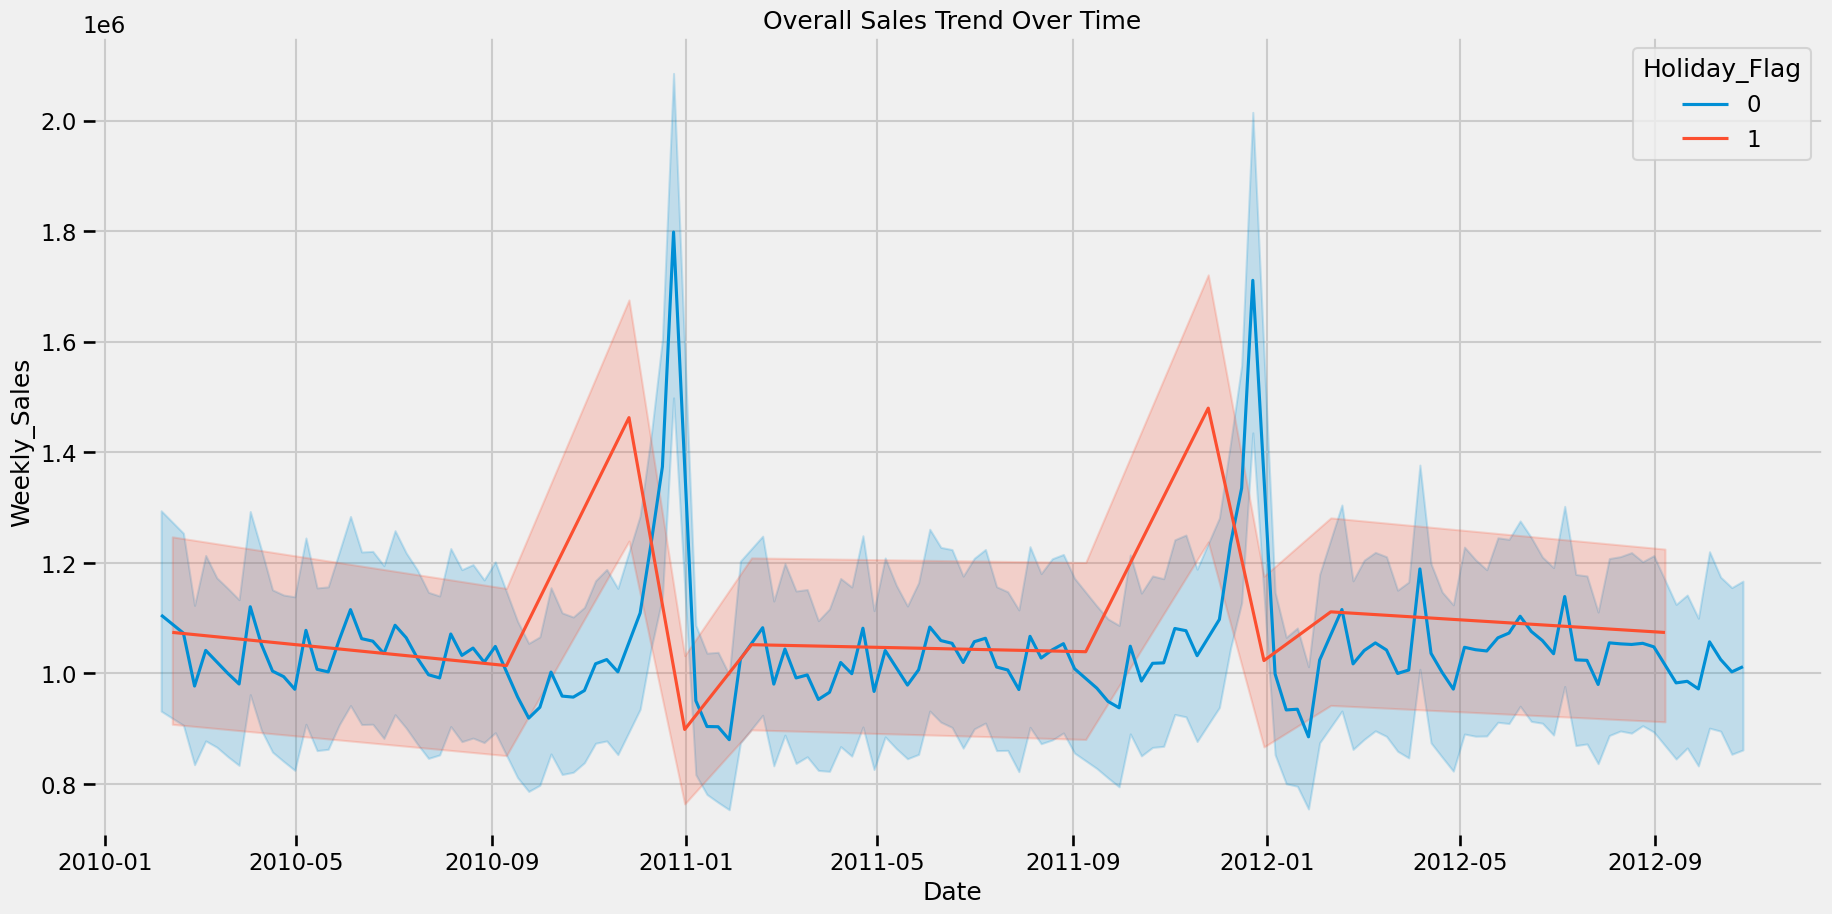

In [135]:
# Now I will start plotting the grapghs in order to know the trends that can provide us with good insights
plt.figure(figsize=(20,10))
plt.style.use('fivethirtyeight')
sns.set_context("talk")
sns.lineplot(data=df, x="Date", y='Weekly_Sales', hue="Holiday_Flag")
plt.xlabel("Date")
plt.ylabel("Weekly_Sales")
plt.title("Overall Sales Trend Over Time")
plt.show()

In [137]:
#By using groupby.maximum, we will know which year was the maximum weekly sale done.
date_sales= df.groupby("Date")["Weekly_Sales"].max().sort_values(ascending=True).reset_index()
date_sales

,Date,Weekly_Sales
0,2010-12-31,1799737.79
1,2011-01-28,1814240.85
2,2011-01-07,1864746.10
3,2010-09-24,1879891.13
4,2011-01-14,1884345.01
...,...,...
138,2010-12-17,2819193.17
139,2010-11-26,2939946.38
140,2011-11-25,3004702.33
141,2011-12-23,3676388.98


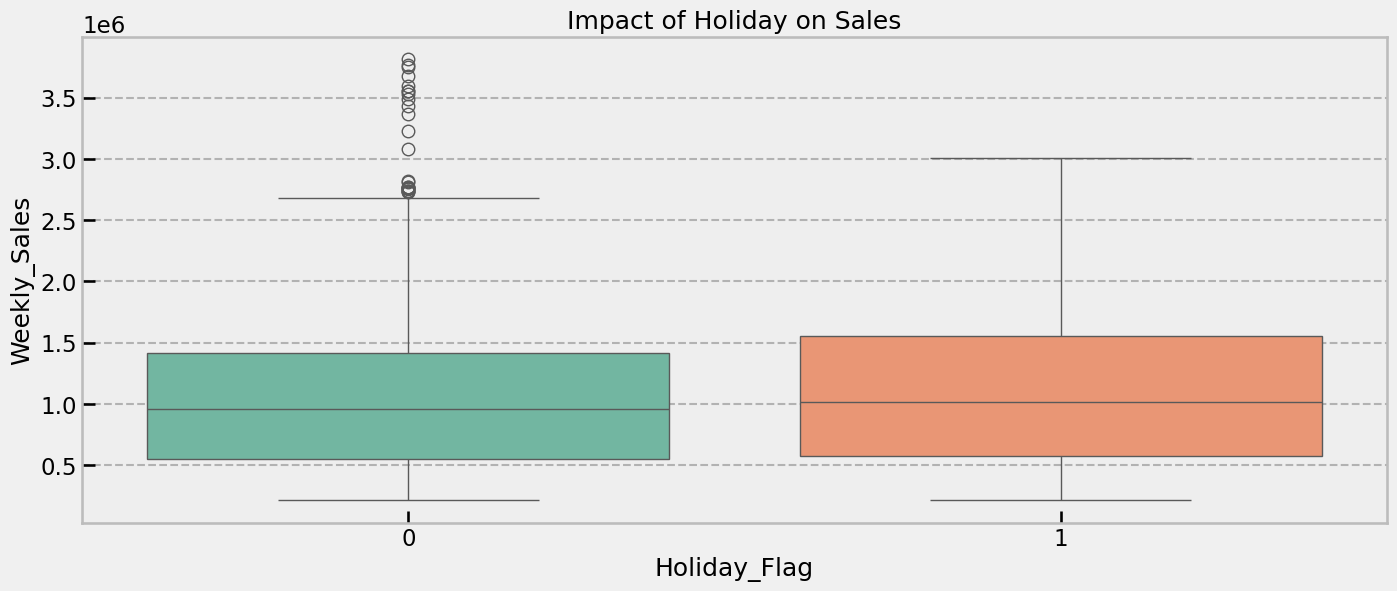

In [121]:
#2 Impact of holday on sales

plt.figure(figsize=(15,6))
plt.style.use('bmh')
sns.set_context("talk")
sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', palette="Set2")
plt.title("Impact of Holiday on Sales")
plt.show()

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

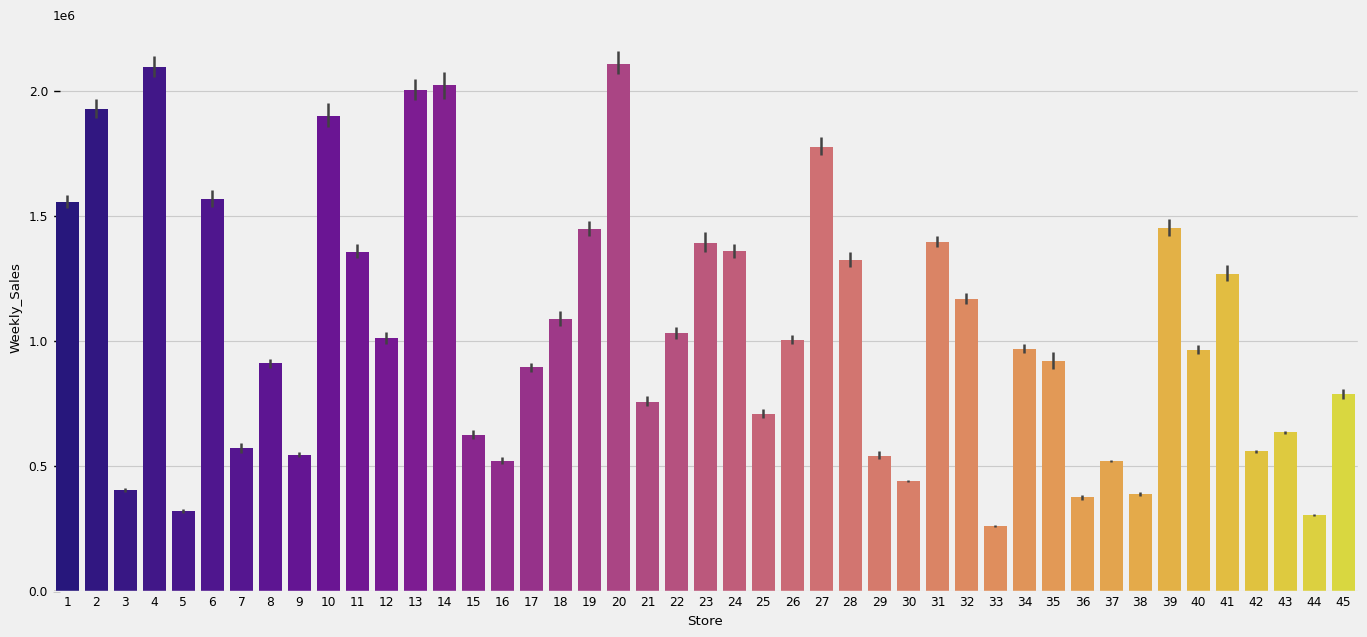

In [125]:
#3 Store Performance with weekly sales
plt.figure(figsize=(15,7))
plt.style.use("fivethirtyeight")
sns.set_context("paper", font_scale=1)
sns.barplot(data=df, x="Store", y="Weekly_Sales", estimator=np.mean, palette="plasma")

In [138]:
highest_salestore= df.groupby("Store")["Weekly_Sales"].median().sort_values(ascending=True).reset_index()
highest_salestore

,Store,Weekly_Sales
0,33,258427.39
1,44,298080.45
2,5,310338.17
3,36,373267.58
4,38,380870.09
5,3,395107.35
6,30,438068.71
7,16,508520.09
8,37,518124.16
9,29,518628.42


In [139]:
df.head(1)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.9,0,42.31,2.572,211.096358,8.106


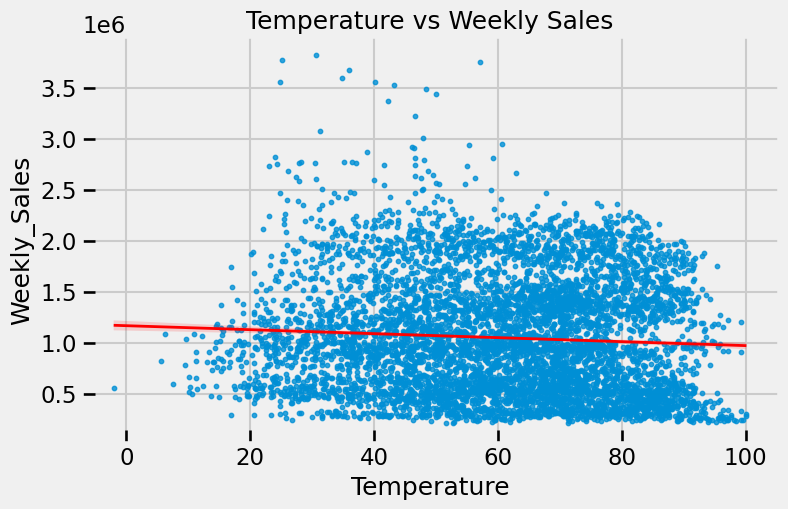

In [140]:
#4 Temprature vs Weekly Sales
# We will now use regplot in-order to know the impact of temprature on the Weekly sales
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="Temperature",
    y="Weekly_Sales",
    scatter_kws={"s": 10},
    line_kws={"color": "red", "linewidth": 2,}
)
plt.title("Temperature vs Weekly Sales")
plt.show()


<Axes: xlabel='Fuel_Price', ylabel='Weekly_Sales'>

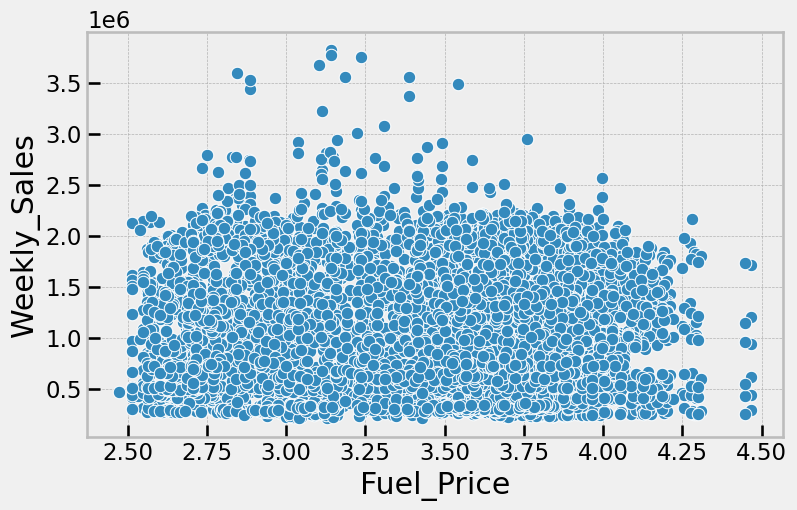

In [141]:
#5 Fuel Prices and sales Condition
#Using a scatter plot to plot how weekly sales were disturbed by the fuel price.
plt.figure(figsize=(8,5))
plt.style.use("bmh")
sns.scatterplot(df, x="Fuel_Price", y="Weekly_Sales")

In [142]:
#Counting the weekly sales in order to know how the fuel prices affected the weekly sales
# we will know that most sales were done with which sort of fuel price as it vaired.
fuelpr= df.groupby("Fuel_Price").count()["Weekly_Sales"].sort_values(ascending=False).reset_index()

In [143]:
fuelpr

,Fuel_Price,Weekly_Sales
0,3.638,39
1,3.630,34
2,2.771,29
3,3.891,29
4,3.524,28
...,...,...
887,2.539,1
888,2.533,1
889,2.520,1
890,2.513,1


<Axes: xlabel='Unemployment', ylabel='Weekly_Sales'>

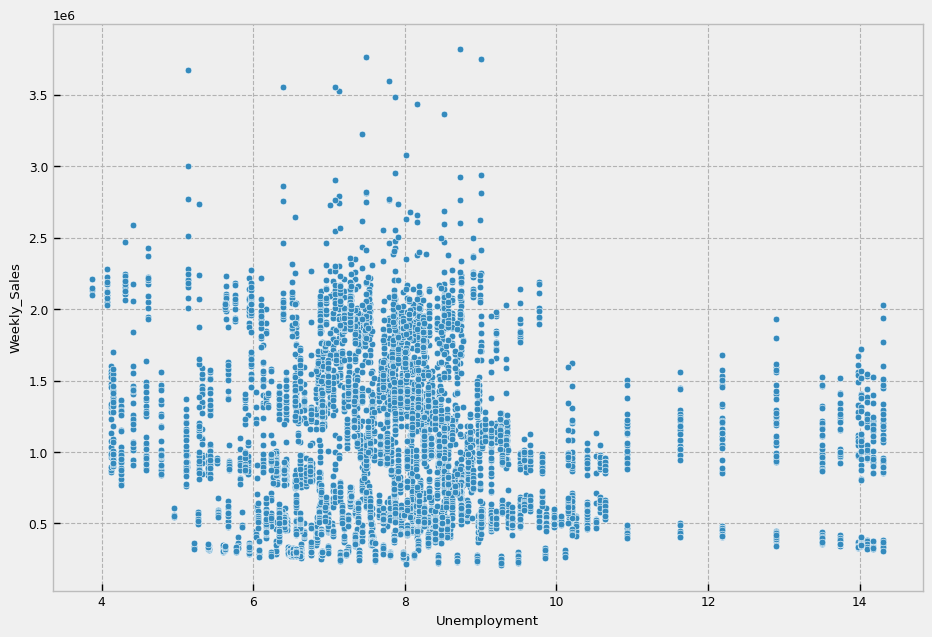

In [144]:
#6 Economic Factors & Sales (CPI & Unemploymenet)
plt.figure(figsize=(10,7))
sns.set_context("paper")
sns.scatterplot(df, x="Unemployment", y="Weekly_Sales")


In [145]:
unemp=df.groupby("Unemployment")['Weekly_Sales'].count().sort_values().reset_index()

In [146]:
unemp

,Unemployment,Weekly_Sales
0,3.879,4
1,5.527,4
2,5.422,4
3,5.847,4
4,6.195,4
...,...,...
344,8.200,52
345,6.565,52
346,8.163,56
347,7.852,56


In [147]:
# In order to proceed with the correlation matrix with which we will make a heat map we need only numerical values and for that we will follow the below steps.

numerical_values=df.select_dtypes(include=[np.number])

In [148]:
numerical_values

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...
6430,45,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,718125.53,0,56.47,3.969,192.330854,8.667


<Axes: >

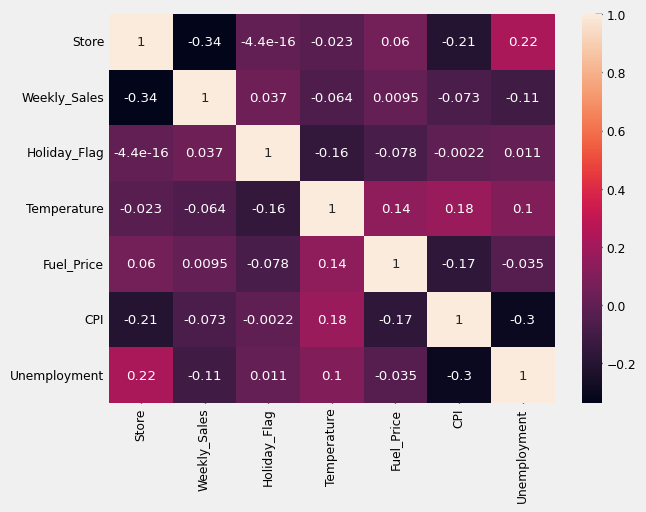

In [149]:
#using the new dataframe made just for the correlation purpose in order to get the heatmap
sns.heatmap(numerical_values.corr(), annot=True)